# Семинар 7 - Детекция и сопоставление ключевых точек

Данный семинар содержит две части: первая с неоцениваемыми опциональными заданиями, и вторая часть с **Домашним заданием**

***

In [1]:
import numpy as np
from scipy import ndimage, stats
from time import perf_counter
import cv2
import matplotlib.pyplot as plt
from itertools import product
import hashlib

sha = lambda a: hashlib.sha256(a.tobytes()).hexdigest()

# Данные

Изображения взяты из папки samples репозитория opencv: https://github.com/opencv/opencv/tree/4.x/samples/data

In [ ]:
from pathlib import Path

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
required_files = ['box.png', 'box_in_scene.png']
missing_files = [name for name in required_files if not (data_dir / name).exists()]



????-??????????? ??? ???????? ????????.


In [3]:
img_1 = cv2.imread('data/box.png', cv2.IMREAD_GRAYSCALE)

img_2 = cv2.imread('data/box_in_scene.png', cv2.IMREAD_GRAYSCALE)

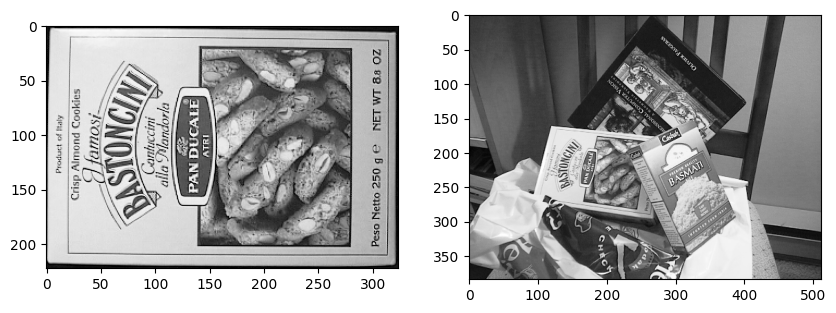

In [4]:
plt.figure(figsize=[10, 10])
plt.subplot(1, 2, 1)
plt.imshow(img_1, cmap='Greys_r')
plt.subplot(1, 2, 2)
plt.imshow(img_2, cmap='Greys_r')

In [5]:
img_1.shape

(223, 324)

# Извлечение ключевых точек: ORB

- Rublee, Ethan, et al. "ORB: An efficient alternative to SIFT or SURF." 2011 International conference on computer vision. Ieee, 2011. [[pdf]](https://d1wqtxts1xzle7.cloudfront.net/63685366/ORB-_An_efficient_alternative_to_SIFT_or_SURF20200619-118758-d5kgfr-libre.pdf?1592635646=&response-content-disposition=inline%3B+filename%3DORB_an_efficient_alternative_to_SIFT_or.pdf&Expires=1678814267&Signature=bylBe0Mp4cefN84Bzcx1RZP0mUe7ZGLkYFAYAZ1~rbgXQtNFXbMryWE-FcG~sYLMhk9hKdwGVzvgLYGb-OZazU5dcsurJl7Fw4Csg7lThUE8Kh~SYK9fqG8XrMpQlUn3hIMrobrTH9qvAMeVBNs0ZCTPmvFI5o04OW73ysIS6BoX0nsLMUxtYZa8zvIJvZJSey6POYB8-IXQO8Jvu0e3mvzwViUXxvByCJwycTHC1oObfH6mFU6cg4A0SPUNdiKdmZOvx0nmhvY96NRuu7aMX8I6mrU6x02NBQZtTRebP3RoQqtBhr-5X~c40uxY-big5AnZu2fc-qP8OWZ0lnx~xg__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)

[Туториал на medium](https://medium.com/@deepanshut041/introduction-to-orb-oriented-fast-and-rotated-brief-4220e8ec40cf)



In [6]:
# Initiate ORB detector
orb = cv2.ORB_create()

# find the keypoints and descriptors with ORB
kp_1, des_1 = orb.detectAndCompute(img_1, None)
kp_2, des_2 = orb.detectAndCompute(img_2, None)

Каждая ключевая точка характеризуется:
1. angle - углом, что позволяет вычислять дескрипторы, инвариантные к повороту,
2. octave - октавой, определяющей масштаб, на котором была обнаружена ключевая точка,
3. pt - субпиксельными координатами этой ключевой точки на изображении, 
4. response - величиной отклика детектора,
5. size - размером (для визуализации величины отклика)

In [7]:
print('type(kp_1) =', type(kp_1))
print('len(kp_1) =', len(kp_1))
print()
print('kp_1[0] =', kp_1[0])
print()
print('kp_1[0].angle = ', kp_1[0].angle)
print('kp_1[0].octave = ', kp_1[0].octave)
print('kp_1[0].pt = ', kp_1[0].pt)
print('kp_1[0].response = ', kp_1[0].response)
print('kp_1[0].size = ', kp_1[0].size)

type(kp_1) = <class 'tuple'>
len(kp_1) = 453

kp_1[0] = < cv2.KeyPoint 00000245B7C5B6F0>

kp_1[0].angle =  357.1012268066406
kp_1[0].octave =  0
kp_1[0].pt =  (83.0, 78.0)
kp_1[0].response =  0.005487026181071997
kp_1[0].size =  31.0


Дескрипторы - это вектора фиксированной длины для каждой ключевой точки

In [8]:
print('type(des_1) =', type(des_1))
print('des_1.shape =', des_1.shape)
print('des_1.dtype =', des_1.dtype)

type(des_1) = <class 'numpy.ndarray'>
des_1.shape = (453, 32)
des_1.dtype = uint8


In [9]:
img_1_kp = cv2.drawKeypoints(img_1, kp_1, None, (255, 0, 0), 4)
img_2_kp = cv2.drawKeypoints(img_2, kp_2, None, (255, 0, 0), 4)

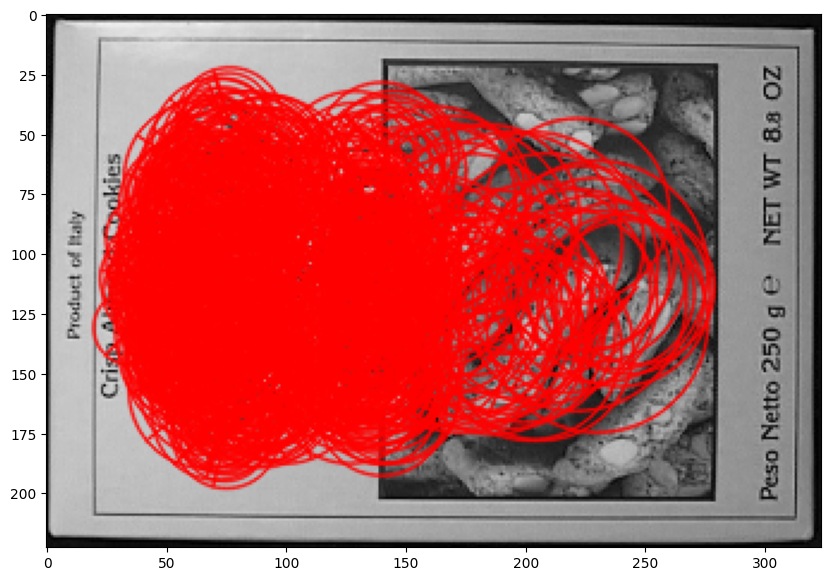

In [10]:
plt.figure(figsize=[10, 10])
plt.imshow(img_1_kp)

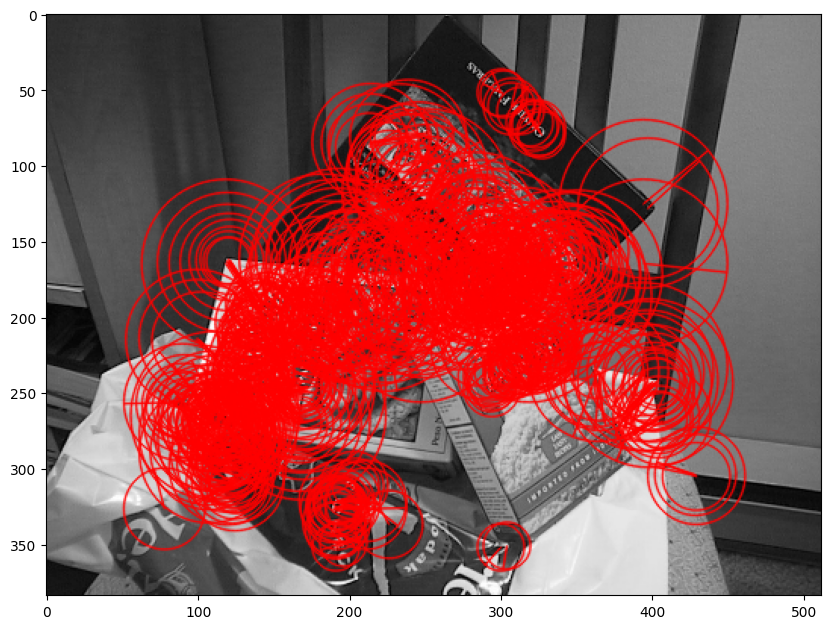

In [11]:
plt.figure(figsize=[10, 10])
plt.imshow(img_2_kp)

# Вопрос 1

_(самостоятельная работа без проверки и оценки)_

О чем говорит наличие концентрических окружностей?

**Ответ:** они показывают, что одна и та же структура была найдена на нескольких масштабах. То есть детектор считает эту область устойчивой и интересной для разных размеров окна.


# Вопрос 2

_(самостоятельная работа без проверки и оценки)_

Каким способом можно избавиться от избыточных близких ключевых точек? И нужно ли это делать?

**Ответ:** можно применить non-maximum suppression, ANMS или кластеризацию по расстоянию и отклику. Делать это не всегда обязательно: плотные точки иногда улучшают матчинг, но прореживание полезно для скорости, удаления дублей и более равномерного покрытия изображения.


# Сопоставление ключевых точек: Brute-Force

[Туториал OpenCV по Feature Matching](https://docs.opencv.org/3.0-beta/doc/py_tutorials/py_feature2d/py_matcher/py_matcher.html#)

Для сопоставления ключевых точек методом грубого перебора можно использовать функцию `cv2.BFMatcher()`.

Она принимает на вход два аргумента:
1. `normType` - какая меру дистанции между дескрипторами будет использоваться
2. `crossCheck` - при значении `True` возвращает только пары (i, j), такие, что i-й дескриптор из первого имеет в качестве наилучшего совпадения j-й дескриптор из второго множества (и наоборот).

In [12]:
matcher = cv2.BFMatcher(cv2.NORM_HAMMING2, crossCheck=True)
matches = matcher.match(des_1, des_2)

# top-20 matches
matches = sorted(matches, key=lambda x: x.distance)
matches = matches[:20]

In [13]:
img_matches = cv2.drawMatches(img_1, kp_1, img_2, kp_2, matches, None, flags=2)

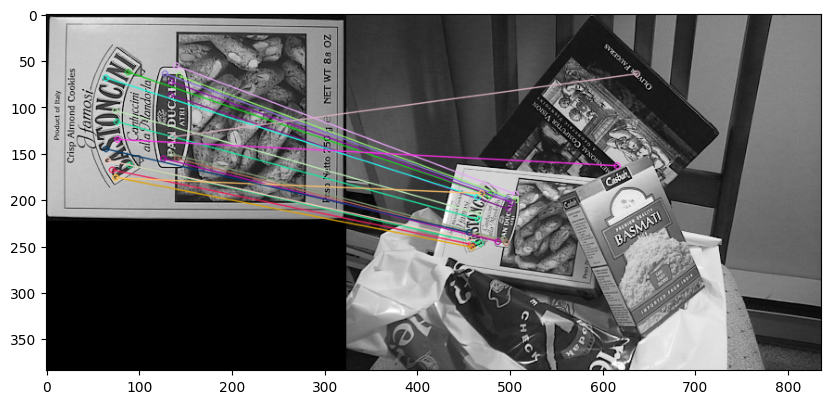

In [14]:
plt.figure(figsize=[10, 10])
plt.imshow(img_matches)

# Выравнивание изображений

In [15]:
src_pts = np.float32([ kp_1[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
dst_pts = np.float32([ kp_2[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)

M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

In [16]:
M

array([[ 4.55329277e-01, -1.21376804e-01,  1.16690636e+02],
       [-1.28757525e-03,  4.66503624e-01,  1.60112868e+02],
       [-2.75831008e-04, -1.05890819e-04,  1.00000000e+00]])

In [17]:
img_1_transformed = cv2.warpPerspective(img_1, M, img_2.shape[0:2][::-1])

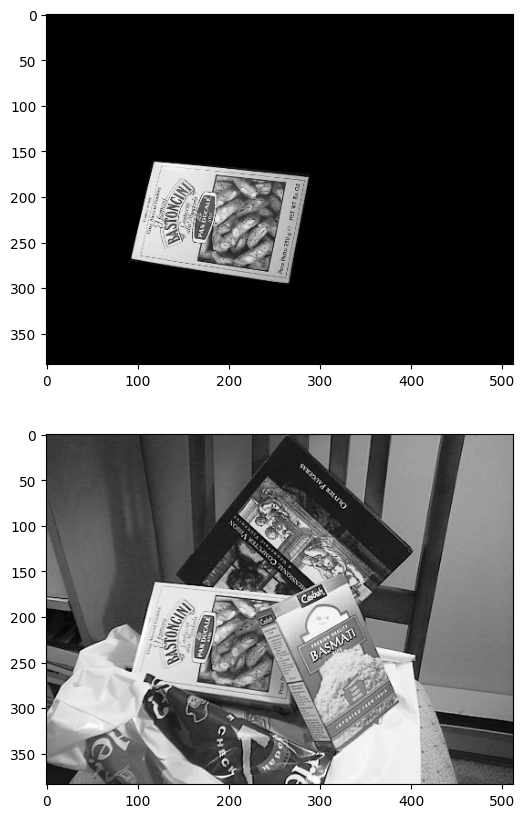

In [18]:
plt.figure(figsize=[20, 10])
plt.subplot(2, 1, 1)
plt.imshow(img_1_transformed, cmap='Greys_r')
plt.subplot(2, 1, 2)
plt.imshow(img_2, cmap='Greys_r')

# SURF

Основные отличия между детекторами ORB (Oriented FAST and Rotated BRIEF) и SURF (Speeded Up Robust Features) заключаются в следующем:

- Скорость: ORB быстрее, чем SURF. Это связано с тем, что ORB использует бинарный дескриптор и более быстрый алгоритм обнаружения ключевых точек (FAST), в то время как SURF использует дескриптор с плавающей запятой и более вычислительно сложный алгоритм обнаружения ключевых точек.
- Инвариантность к масштабу: SURF обладает более высокой инвариантностью к масштабу, чем ORB. Это связано с тем, что SURF использует представление изображения в масштабированном виде (scale-space representation of the image) для обнаружения ключевых точек на разных масштабах, тогда как ORB использует фиксированный размер пирамиды масштабов (fixed-size scale pyramid).
- Инвариантность к повороту: ORB более инвариантен к повороту, чем SURF. ORB вычисляет дескриптор, который инвариантен к повороту, в то время как SURF вычисляет дескриптор, который не полностью инвариантен к повороту, но может быть сделан таковым с помощью дополнительных вычислений.
- Устойчивость к шуму и размытию: SURF в целом более устойчив к шуму и размытию, чем ORB, из-за использования в процессе обнаружения ключевых точек гауссовского фильтра.

[Туториал на medium](https://medium.com/@deepanshut041/introduction-to-surf-speeded-up-robust-features-c7396d6e7c4e)

**Основным заданием** будет ознакомиться со статьями:

1. [Speeded-Up Robust Features (SURF)](https://www.sciencedirect.com/science/article/pii/S1077314207001555)
2. [An Analysis of the SURF Method](https://www.ipol.im/pub/art/2015/69/article_lr.pdf) (опционально, расширенный анализ метода)

Опираясь на статьи, необходимо дополнить недостающие строчки кода. Во многих местах достаточно одной строки, реализующей ту или иную операцию.

Сначала ознакомьтесь со вспомогательными функциями:

In [19]:
def integral_image(image):
    '''Вычисляет интегральное изображение
    '''
    return image.cumsum(axis=0).cumsum(axis=1)


def partial_sums(integral, x, y, w, h, kernel_size, spatial_step):
    '''Вычисляет свертку изображения на основе интегрального изображения.
    Ядро свертки имеет размер kernel_size x kernel_size и движется
    с шагом spatial_step.

    По изображению движется ядро размера kernel_size x kernel_size
    с шагом spatial_step. Это ядро состоит из нулей, кроме прямоугольника
    с верхним левым углом (x, y) и размерами (ширина, высота) = (w, h).
    '''
    H, W = integral.shape[:2]
    integral = np.pad(integral, 1)
    x, y = x + 1, y + 1

    y1 = y - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x - 1
    x2 = W - (kernel_size - x1) + 1
    b1 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    y1 = y - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x + w - 1
    x2 = W - (kernel_size - x1) + 1
    b2 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    y1 = y + h - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x - 1
    x2 = W - (kernel_size - x1) + 1
    b3 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    y1 = y + h - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x + w - 1
    x2 = W - (kernel_size - x1) + 1
    b4 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    return b4 - b2 - b3 + b1

# Задание 1: Вспомогательные функции

_(самостоятельная работа без проверки и оценки)_

Допишите оператор return в тех функциях, где это необходимо.

In [20]:
def Dx(integral, kernel_size):
    '''Первая производная по X
    '''
    left = partial_sums(integral, 0, 0, kernel_size // 2, kernel_size, kernel_size, 1)
    right = partial_sums(integral, kernel_size // 2, 0, kernel_size // 2, kernel_size, kernel_size, 1)
    return right - left


def Dy(integral, kernel_size):
    '''Первая производная по Y
    '''
    up = partial_sums(integral, 0, 0, kernel_size, kernel_size // 2, kernel_size, 1)
    bottom = partial_sums(integral, 0, kernel_size // 2, kernel_size, kernel_size // 2, kernel_size, 1)
    return bottom - up


def Dxx(integral, kernel_size, spatial_step):
    '''Вторая производная по X
    '''
    shift = round(kernel_size * 2 / 9)
    h = kernel_size - 2 * shift

    w1 = round(kernel_size / 3)
    w2 = round(kernel_size / 3)
    w3 = kernel_size - w1 - w2

    c1 = (3 * 5) / (w1 * h)
    c2 = (3 * 5) / (w2 * h)
    c3 = (3 * 5) / (w3 * h)

    left = partial_sums(integral, 0, shift, w1, h, kernel_size, spatial_step)
    center = partial_sums(integral, 0 + w1, shift, w2, h, kernel_size, spatial_step)
    right = partial_sums(integral, 0 + w1 + w2, shift, w3, h, kernel_size, spatial_step)

    return c1 * left - 2 * c2 * center + c3 * right


def Dyy(integral, kernel_size, spatial_step):
    '''Вторая производная по Y
    '''
    shift = round(kernel_size * 2 / 9)
    w = kernel_size - 2 * shift

    h1 = round(kernel_size / 3)
    h2 = round(kernel_size / 3)
    h3 = kernel_size - h1 - h2

    c1 = (3 * 5) / (h1 * w)
    c2 = (3 * 5) / (h2 * w)
    c3 = (3 * 5) / (h3 * w)

    top = partial_sums(integral, shift, 0, w, h1, kernel_size, spatial_step)
    center = partial_sums(integral, shift, 0 + h1, w, h2, kernel_size, spatial_step)
    bottom = partial_sums(integral, shift, 0 + h1 + h2, w, h3, kernel_size, spatial_step)

    return c1 * top - 2 * c2 * center + c3 * bottom


def Dxy(integral, kernel_size, spatial_step):
    '''Смешанная производная по XY
    '''
    shift_1 = round(kernel_size * 1 / 9)
    shift_2 = round(kernel_size * 5 / 9)
    size = round(kernel_size * 3 / 9)

    c = (3 * 3) / (size * size)

    b11 = partial_sums(integral, shift_1, shift_1, size, size, kernel_size, spatial_step)
    b21 = partial_sums(integral, shift_1, shift_2, size, size, kernel_size, spatial_step)
    b12 = partial_sums(integral, shift_2, shift_1, size, size, kernel_size, spatial_step)
    b22 = partial_sums(integral, shift_2, shift_2, size, size, kernel_size, spatial_step)

    return c * (b11 + b22 - b12 - b21)


def det_H_approx(integral, kernel_size, spatial_step):
    '''Приближенное значение определителя гессиана
    '''
    Dxx_image = Dxx(integral, kernel_size, spatial_step)
    Dyy_image = Dyy(integral, kernel_size, spatial_step)
    Dxy_image = Dxy(integral, kernel_size, spatial_step)
    return Dxx_image * Dyy_image - (0.9 * Dxy_image) ** 2


def haar_approx(integral, kernel_size):
    Dx_image = Dx(integral, kernel_size)
    Dy_image = Dy(integral, kernel_size)
    return np.stack((Dx_image, Dy_image), axis=0)


Проверьте правильность реализации:

In [21]:
img_test = img_1[:100, :100]
integral = integral_image(img_test)

a = Dx(integral, 9)
assert(a.shape == (92, 92))
assert(sha(a) == '8443801ac6710847e145b1475ab5b46c62ffbf93a7c9f3cb6c6545e472b3055c')

a = Dy(integral, 9)
assert(a.shape == (92, 92))
assert(sha(a) == '86efd03cc4121d3971ae815d1313a747afbc2a2f731439a4fdbccb023c12ea91')

a = Dxx(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a) == '6bc290652bdc4097d0c586156bf34be79c6bc7bb4349deb81825906e05d990c4')

a = Dyy(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a)== '32eb1373fa7cfb32bd73ae4c488a06ccf60aea2c54a5506b0b5a1fe7b012fb71')

a = Dxy(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a) == '67117a8e240a7621d9a587ad657c782fef9496d4116bed831e178024b4fb7202')

a = det_H_approx(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a) == 'ee35655b446302b24b7c820f4f5268d8aff1ed81ae7d5947ca0ec464dcb68497')

# Задание 2: Детектор ключевых точек

_(самостоятельная работа без проверки и оценки)_

1. В функции _init_pyramid заполните параметры пирамиды изображений правильными значениями
2. Релизуйте функцию _is_maxima, проверяющую, что центральный элемент кубика N27 размера 3x3x3, является максимальными среди всех элементов N27
3. Допишите функцию _interpolate_keypoint, вычисляющую положение субпиксельного максимума в N27

In [22]:
class FastHessianDetector:

    def __init__(self, hessian_threshold, n_octaves=4, n_octave_layers=4):
        self.hessian_threshold = hessian_threshold
        self.n_octaves = n_octaves
        self.n_octave_layers = n_octave_layers
        self.pyramid = None

        self.pyramid_internal_layers = []
        self.pyramid_parameters = []
        self._init_pyramid()

    def detect(self, image):
        pyramid = self._build_pyramid(image.astype(np.float32))

        keypoints = []
        for internal_layer in self.pyramid_internal_layers:
            layer_keypoints = self._extract_layer_keypoints(pyramid, internal_layer)
            keypoints.extend(layer_keypoints)

        return keypoints

    def _init_pyramid(self):
        index = 0
        for octave in range(1, self.n_octaves + 1):
            for layer in range(1, self.n_octave_layers + 1):
                kernel_size = 3 * ((2 ** octave) * layer + 1)
                spatial_step = 2 ** (octave - 1)
                scale = 1.2 * kernel_size / 9
                scale_step = 1.2 * (3 * (2 ** octave)) / 9
                self.pyramid_parameters.append((kernel_size, spatial_step, scale, scale_step))
                if 1 < layer < self.n_octave_layers:
                    self.pyramid_internal_layers.append(index)
                index += 1

    def _build_pyramid(self, image):
        padding = (max([kernel_size for kernel_size, spatial_step, scale, scale_step in self.pyramid_parameters]) - 1) // 2
        imgage_padded = np.pad(image, padding)

        integral = integral_image(imgage_padded)
        H, W = integral.shape

        pyramid = []
        for kernel_size, spatial_step, scale, scale_step in self.pyramid_parameters:
            empty_size = padding - (kernel_size - 1) // 2
            pyramid_layer = det_H_approx(
                integral[empty_size:H - empty_size, empty_size:W - empty_size],
                kernel_size,
                spatial_step
            )
            pyramid.append(pyramid_layer)

        return pyramid

    def _extract_layer_keypoints(self, pyramid, internal_layer):
        H, W = pyramid[internal_layer].shape

        layer_keypoints = []
        maximas = []
        for y in range(1, H - 1):
            for x in range(1, W - 1):
                N27 = self._get_N27(pyramid, internal_layer, x, y)
                magnitude = N27[1, 1, 1]
                if self._is_maxima(N27) and magnitude >= self.hessian_threshold:
                    status, local_keypoint = self._interpolate_keypoint(N27)
                    if status:
                        keypoint = self._project_keypoint(local_keypoint, internal_layer, x, y)
                        layer_keypoints.append(keypoint)
                        maximas.append(magnitude)
        layer_keypoints = [layer_keypoints[i] for i in np.argsort(maximas)[::-1]]
        return layer_keypoints

    def _get_N27(self, pyramid, internal_layer, x, y):
        l = internal_layer
        N27 = np.array([[
            [pyramid[l - 1][y - 1, x - 1], pyramid[l - 1][y - 1, x], pyramid[l - 1][y - 1, x + 1]],
            [pyramid[l - 1][y, x - 1],     pyramid[l - 1][y, x],     pyramid[l - 1][y, x + 1]],
            [pyramid[l - 1][y + 1, x - 1], pyramid[l - 1][y + 1, x], pyramid[l - 1][y + 1, x + 1]]
        ], [
            [pyramid[l][y - 1, x - 1], pyramid[l][y - 1, x], pyramid[l][y - 1, x + 1]],
            [pyramid[l][y, x - 1],     pyramid[l][y, x],     pyramid[l][y, x + 1]],
            [pyramid[l][y + 1, x - 1], pyramid[l][y + 1, x], pyramid[l][y + 1, x + 1]]
        ], [
            [pyramid[l + 1][y - 1, x - 1], pyramid[l + 1][y - 1, x], pyramid[l + 1][y - 1, x + 1]],
            [pyramid[l + 1][y, x - 1],     pyramid[l + 1][y, x],     pyramid[l + 1][y, x + 1]],
            [pyramid[l + 1][y + 1, x - 1], pyramid[l + 1][y + 1, x], pyramid[l + 1][y + 1, x + 1]]
        ]])
        return N27

    def _is_maxima(self, N27):
        center = N27[1, 1, 1]
        return center == N27.max() and np.count_nonzero(N27 == center) == 1

    def _interpolate_keypoint(self, N27):
        dL_dx = self._gradient(N27)
        d2L_d2x = self._hessian(N27)
        try:
            local_keypoint = np.linalg.solve(d2L_d2x, -dL_dx)
            status = (np.abs(local_keypoint) <= 1).all()
        except np.linalg.LinAlgError:
            local_keypoint = None
            status = False
        return status, local_keypoint

    def _first_derivative(self, N27, axis):
        index_0, index_2 = [1, 1, 1], [1, 1, 1]
        index_0[axis] = 0
        index_2[axis] = 2
        index_0, index_2 = tuple(index_0), tuple(index_2)
        return (N27[index_2] - N27[index_0]) / 2

    def _gradient(self, N27):
        return np.array([self._first_derivative(N27, axis) for axis in range(3)])

    def _second_derivative(self, N27, axes):
        if axes[0] == axes[1]:
            return self._double_derivative(N27, axes[0])
        else:
            return self._mixed_derivative(N27, axes)

    def _double_derivative(self, N27, axis):
        index_0, index_2 = [1, 1, 1], [1, 1, 1]
        index_0[axis] = 0
        index_2[axis] = 2
        index_0, index_2 = tuple(index_0), tuple(index_2)
        return N27[index_2] - 2 * N27[1, 1, 1] + N27[index_0]

    def _mixed_derivative(self, N27, axes):
        index_0_0, index_2_0 = [1, 1, 1], [1, 1, 1]
        index_0_0[axes[0]] = 0
        index_2_0[axes[0]] = 2
        index_0_0[axes[1]] = index_2_0[axes[1]] = 0
        index_0_0, index_2_0 = tuple(index_0_0), tuple(index_2_0)

        index_0_2, index_2_2 = [1, 1, 1], [1, 1, 1]
        index_0_2[axes[0]] = 0
        index_2_2[axes[0]] = 2
        index_0_2[axes[1]] = index_2_2[axes[1]] = 2
        index_0_2, index_2_2 = tuple(index_0_2), tuple(index_2_2)

        return ((N27[index_2_2] - N27[index_0_2]) - (N27[index_2_0] - N27[index_0_0])) / 4

    def _hessian(self, N27):
        return np.array([
            self._second_derivative(N27, axes) for axes in product(range(3), repeat=2)
        ]).reshape(3, 3)

    def _project_keypoint(self, local_keypoint, internal_layer, x, y):
        kernel_size, spatial_step, scale, scale_step = self.pyramid_parameters[internal_layer]
        local_scale, local_x, local_y = local_keypoint

        scale = scale + local_scale * scale_step
        x = (x + local_x + 0.5) * spatial_step
        y = (y + local_y + 0.5) * spatial_step

        return [scale, x, y]


Проверьте правильность реализации:

In [23]:
detector = FastHessianDetector(1000000, n_octaves=3)

img_test = img_1.copy()

keypoints = detector.detect(img_test)

a = np.array(keypoints)

# отдельным челленджем для Вас может стать задача получить результат в точности, как у меня
# для этого я оставил здесь эти ассерты
# но это не обязательно - вы можете решить задачу чуть-чуть иначе, но при этом логически правильно

# assert(a.shape == (126, 3))
# assert(sha(a) == '91724ac19651c85852e8de4d8f9a99f65a1ef825d5a03fe0e81821451708d109')

# Задание 3: Оценка ориентации ключевых точек

1. В функции _init_pyramid заполните параметры пирамиды изображений правильными значениями
2. В функции _estimate_orientation допишите расчет радиуса окресности точки (2.a) и параметров нормального распределения (2.b), задающего вес точек в этой окрестности, через масштаб, на котором обнаружена ключевая точка, а также допишите вычисление нормы градиента (2.c).

In [24]:
class OrientationEstimator:

    def __init__(self, n_octaves=4, n_octave_layers=4):
        self.n_octaves = n_octaves
        self.n_octave_layers = n_octave_layers

        self.pyramid_parameters = []
        self._init_pyramid()

    def _init_pyramid(self):
        for octave in range(1, self.n_octaves + 1):
            for layer in range(1, self.n_octave_layers + 1):
                scale = 1.2 * (3 * ((2 ** octave) * layer + 1)) / 9
                kernel_size = int(4 * scale)
                kernel_size += kernel_size % 2
                self.pyramid_parameters.append((scale, kernel_size))

    def estimate(self, image, keypoints):
        pyramid = self._build_pyramid(image.astype(np.float32))

        oriented_keypoints = []
        for keypoint in keypoints:
            orientation = self._estimage_orientation(pyramid, keypoint)
            oriented_keypoints.append((keypoint + [orientation]))

        return oriented_keypoints

    def _build_pyramid(self, image):
        padding = max([kernel_size for scale, kernel_size in self.pyramid_parameters]) // 2
        imgage_padded = np.pad(image, padding)

        integral = integral_image(imgage_padded)
        H, W = integral.shape

        pyramid = []
        for scale, kernel_size in self.pyramid_parameters:
            empty_size = padding - kernel_size // 2
            pyramid_layer = haar_approx(
                integral[empty_size:H - empty_size, empty_size:W - empty_size],
                kernel_size
            )
            pyramid.append(pyramid_layer)

        return pyramid

    def _estimage_orientation(self, pyramid, keypoint):
        scale, x, y = keypoint
        layer = self._find_nearest_layer(scale)
        Dx_image, Dy_image = pyramid[layer]

        center = int(x), int(y)
        radius = 6 * scale

        Dx_polar = cv2.linearPolar(Dx_image, center, radius, cv2.WARP_FILL_OUTLIERS)
        Dy_polar = cv2.linearPolar(Dy_image, center, radius, cv2.WARP_FILL_OUTLIERS)

        Dx_polar = ndimage.zoom(Dx_polar, (360 / Dx_polar.shape[0], int(radius) / Dx_polar.shape[1]))
        Dy_polar = ndimage.zoom(Dy_polar, (360 / Dy_polar.shape[0], int(radius) / Dy_polar.shape[1]))

        sigma = 2.5 * scale
        gauss_kernel = stats.norm(scale=sigma).pdf(np.arange(0, int(radius)))
        Dx_polar = (Dx_polar * gauss_kernel).sum(axis=1)
        Dy_polar = (Dy_polar * gauss_kernel).sum(axis=1)

        Dx_polar = np.concatenate((Dx_polar, Dx_polar[:60]), axis=0)
        Dy_polar = np.concatenate((Dy_polar, Dy_polar[:60]), axis=0)

        Dx_polar_cm = Dx_polar.cumsum(axis=0)
        Dy_polar_cm = Dy_polar.cumsum(axis=0)

        Dx_sum = Dx_polar_cm[60:] - Dx_polar_cm[:-60]
        Dy_sum = Dy_polar_cm[60:] - Dy_polar_cm[:-60]

        grad_norm = Dx_sum ** 2 + Dy_sum ** 2

        orientation = (np.argmax(grad_norm) + 30) % 360

        return orientation

    def _find_nearest_layer(self, scale):
        layer = min([(np.abs(scale - s), layer)
            for layer, (s, _) in enumerate(self.pyramid_parameters)])[1]
        return layer


Проверьте правильность реализации:

In [25]:
estimator = OrientationEstimator()

oriented_keypoints = estimator.estimate(img_test, keypoints)

a = np.array(oriented_keypoints)

# отдельным челленджем для Вас может стать задача получить результат в точности, как у меня
# для этого я оставил здесь эти ассерты
# но это не обязательно - вы можете решить задачу чуть-чуть иначе, но при этом логически правильно

# assert(a.shape == (126, 4))
# assert(sha(a) == 'd24fcfafbc3d194b8da5e2fae3d85a1e376509a10245e440d54c823cb2acd7a8')

# Задание 4: Формирование SURF дескриптора

В функции вычисления дескриптора сформируйте:
1. sigma - параметр нормального распределения, определяющего веса градиентов в окрестности точки
2. Dx_image, Dy_image - перевзвешенные градиетны с гауссовыми весами
3. Сохранение дескриптора

In [26]:
class SURFDescriptor:

    def compute(self, image, keypoints):
        descriptors = []
        for scale, x, y, orientation in keypoints:
            kernel_size = int(2 * scale)
            kernel_size += kernel_size % 2
            window_size = int(20 * scale)
            window_size += 4 - window_size % 4

            u = np.cos(np.pi * orientation / 180), np.sin(np.pi * orientation / 180)
            v = np.sin(np.pi * orientation / 180), -np.cos(np.pi * orientation / 180)
            src = np.array([
                [x + (u[0] + v[0]) * window_size, y + (u[1] + v[1]) * window_size],
                [x + (u[0] - v[0]) * window_size, y + (u[1] - v[1]) * window_size],
                [x + (-u[0] - v[0]) * window_size, y + (-u[1] - v[1]) * window_size],
                [x + (-u[0] + v[0]) * window_size, y + (-u[1] + v[1]) * window_size]
            ], dtype=np.float32)
            dst = np.array([[0, 0], [0, window_size], [window_size, window_size], [window_size, 0]], dtype=np.float32)
            M = cv2.getPerspectiveTransform(src, dst)

            patch = cv2.warpPerspective(image, M, (window_size, window_size))
            patch = np.pad(patch, kernel_size // 2)

            integral = integral_image(patch)
            Dx_image = Dx(integral, kernel_size)[:-1, :-1]
            Dy_image = Dy(integral, kernel_size)[:-1, :-1]

            sigma = 3.3 * scale
            gauss_kernel = stats.norm(scale=sigma).pdf(np.arange(-window_size//2, (window_size+1)//2))
            gauss_weights = np.outer(gauss_kernel, gauss_kernel)
            Dx_image = Dx_image * gauss_weights
            Dy_image = Dy_image * gauss_weights

            descriptor = []
            for i in range(4):
                for j in range(4):
                    i1, i2 = i * window_size // 4, (i + 1) * window_size // 4
                    j1, j2 = j * window_size // 4, (j + 1) * window_size // 4
                    dx = Dx_image[i1:i2, j1:j2].sum()
                    dy = Dy_image[i1:i2, j1:j2].sum()
                    dx_abs = np.abs(Dx_image[i1:i2, j1:j2]).sum()
                    dy_abs = np.abs(Dy_image[i1:i2, j1:j2]).sum()
                    descriptor.extend([dx, dy, dx_abs, dy_abs])
            descriptor = np.array(descriptor)
            descriptor_norm = np.linalg.norm(descriptor)
            descriptors.append(descriptor / max(descriptor_norm, 1e-12))

        return descriptors


In [27]:
extractor = SURFDescriptor()

descriptors = extractor.compute(img_test, oriented_keypoints)

a = np.array(descriptors)

# отдельным челленджем для Вас может стать задача получить результат в точности, как у меня
# для этого я оставил здесь эти ассерты
# но это не обязательно - вы можете решить задачу чуть-чуть иначе, но при этом логически правильно

# assert(a.shape == (126, 64))
# assert(sha(a) == 'e57cbe0be2d1656c91def741f9b6c016539de82512df00b6229602e09c8f12ac')

# FastHessianDetector + OrientationEstimator + SURFDescriptor

In [28]:
def detect_and_draw(img):
    print('Image resolution:', img.shape)
    detector = FastHessianDetector(1000000)
    estimator = OrientationEstimator()
    extractor = SURFDescriptor()

    start = perf_counter()
    keypoints = detector.detect(img)
    end = perf_counter()
    print('Keypoint extraction:', end - start, 's')

    start = perf_counter()
    oriented_keypoints = estimator.estimate(img, keypoints)
    end = perf_counter()
    print('Keypoint orientation estimation:', end - start, 's')

    start = perf_counter()
    descriptors = extractor.compute(img, oriented_keypoints)
    end = perf_counter()
    print('Descriptor extraction:', end - start, 's')
    print()

    kps = [cv2.KeyPoint(float(kp[1]), float(kp[2]), float(kp[0]), float(kp[3])) for kp in oriented_keypoints]
    img_kps = cv2.drawKeypoints(img, kps, None, (255, 0, 0), 4)

    return img_kps, kps, np.array(descriptors, dtype=np.float32)

# Домашняя работа

**А вот это уже настоящее оцениваемое задание**

## Задача 1

Вспомните семинар 4, с картиной "Амбассадоры". Реализуйте детекцию и сопоставление ключевых точек с помощью **любого классического метода**. Найдите трансформацию, выровняйте череп на картине.

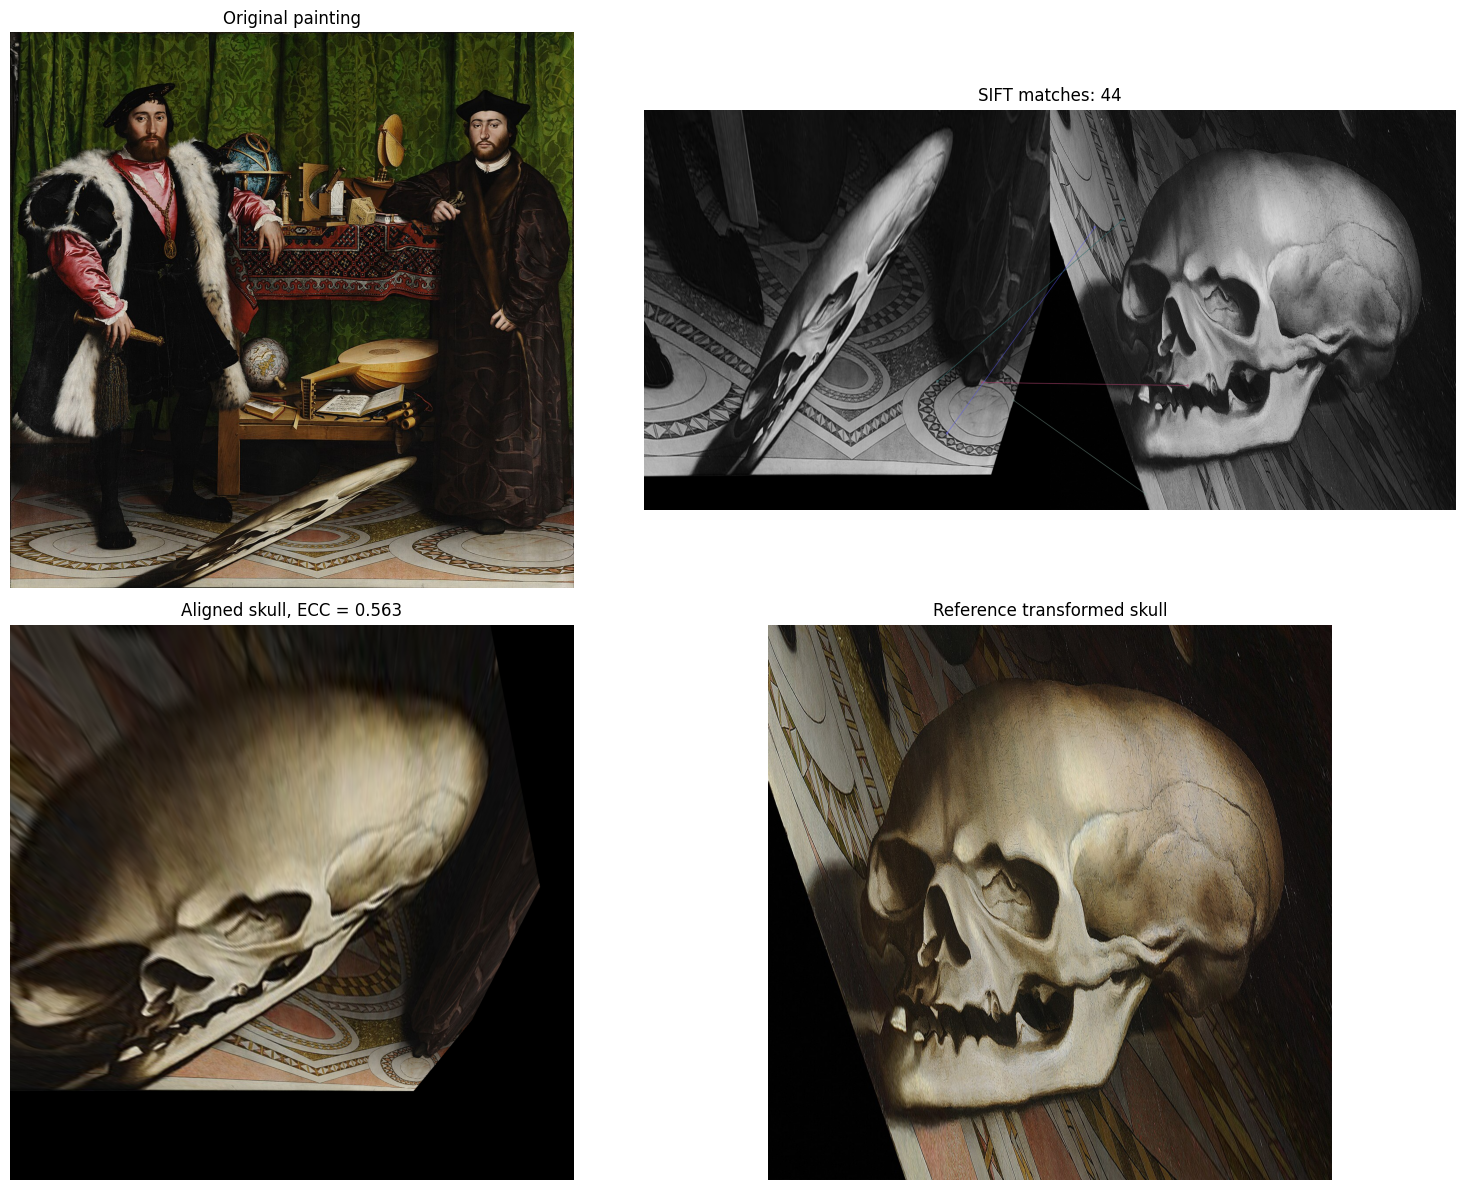

Good SIFT matches: 44
ECC correlation coefficient: 0.5625495074300533


In [29]:
orig_bgr = cv2.imread('data/the_ambassadors.jpg')
ref_bgr = cv2.imread('data/the_ambassadors_skull_transformed.jpg')

orig_gray = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2GRAY)
ref_gray = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2GRAY)
ref_h, ref_w = ref_gray.shape

# Rough projective normalization from seminar 4.
src_pts = np.float32([
    [420, 1020],
    [1020, 960],
    [1160, 1255],
    [300, 1255],
])
dst_pts = np.float32([
    [130, 120],
    [1100, 120],
    [1020, 1140],
    [220, 1140],
])
H_init = cv2.getPerspectiveTransform(src_pts, dst_pts)
rough_bgr = cv2.warpPerspective(orig_bgr, H_init, (ref_w, ref_h))
rough_gray = cv2.cvtColor(rough_bgr, cv2.COLOR_BGR2GRAY)

# Classical matching: SIFT between the roughly normalized skull and the reference skull.
mask_ref = np.uint8(ref_gray > 5) * 255
mask_rough = np.uint8(rough_gray > 5) * 255
sift = cv2.SIFT_create(nfeatures=4000)
kp_rough, des_rough = sift.detectAndCompute(rough_gray, mask_rough)
kp_ref, des_ref = sift.detectAndCompute(ref_gray, mask_ref)
matcher = cv2.BFMatcher(cv2.NORM_L2)
knn_matches = matcher.knnMatch(des_rough, des_ref, k=2)
good_matches = [m for m, n in knn_matches if m.distance < 0.75 * n.distance]

inlier_mask = None
if len(good_matches) >= 4:
    pts_rough = np.float32([kp_rough[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts_ref = np.float32([kp_ref[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    _, sift_mask = cv2.findHomography(pts_rough, pts_ref, cv2.USAC_MAGSAC, 5.0)
    if sift_mask is not None:
        inlier_mask = sift_mask.ravel().tolist()

matches_vis = cv2.drawMatches(
    rough_gray,
    kp_rough,
    ref_gray,
    kp_ref,
    good_matches[:80],
    None,
    matchesMask=None if inlier_mask is None else inlier_mask[:80],
    flags=2,
)

# Refine alignment with classical ECC registration.
warp_ecc = np.eye(3, 3, dtype=np.float32)
criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 200, 1e-6)
cc, warp_ecc = cv2.findTransformECC(
    ref_gray.astype(np.float32) / 255.0,
    rough_gray.astype(np.float32) / 255.0,
    warp_ecc,
    cv2.MOTION_HOMOGRAPHY,
    criteria,
)
aligned_bgr = cv2.warpPerspective(
    rough_bgr,
    warp_ecc,
    (ref_w, ref_h),
    flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs[0, 0].imshow(cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title('Original painting')
axs[0, 1].imshow(matches_vis, cmap='gray')
axs[0, 1].set_title(f'SIFT matches: {len(good_matches)}')
axs[1, 0].imshow(cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB))
axs[1, 0].set_title(f'Aligned skull, ECC = {cc:.3f}')
axs[1, 1].imshow(cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2RGB))
axs[1, 1].set_title('Reference transformed skull')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Good SIFT matches:', len(good_matches))
print('ECC correlation coefficient:', cc)


## Задача 2

Сделайте два фото одного и того же объекта с разных ракурсов.
Теперь **используйте SuperPoint для нахождения ключевых точек** на этих изображениях (веса - возьмите готовые).
Затем **используйте SuperGlue для сопоставления этих ключевых точек**.
Визуализируйте результат.

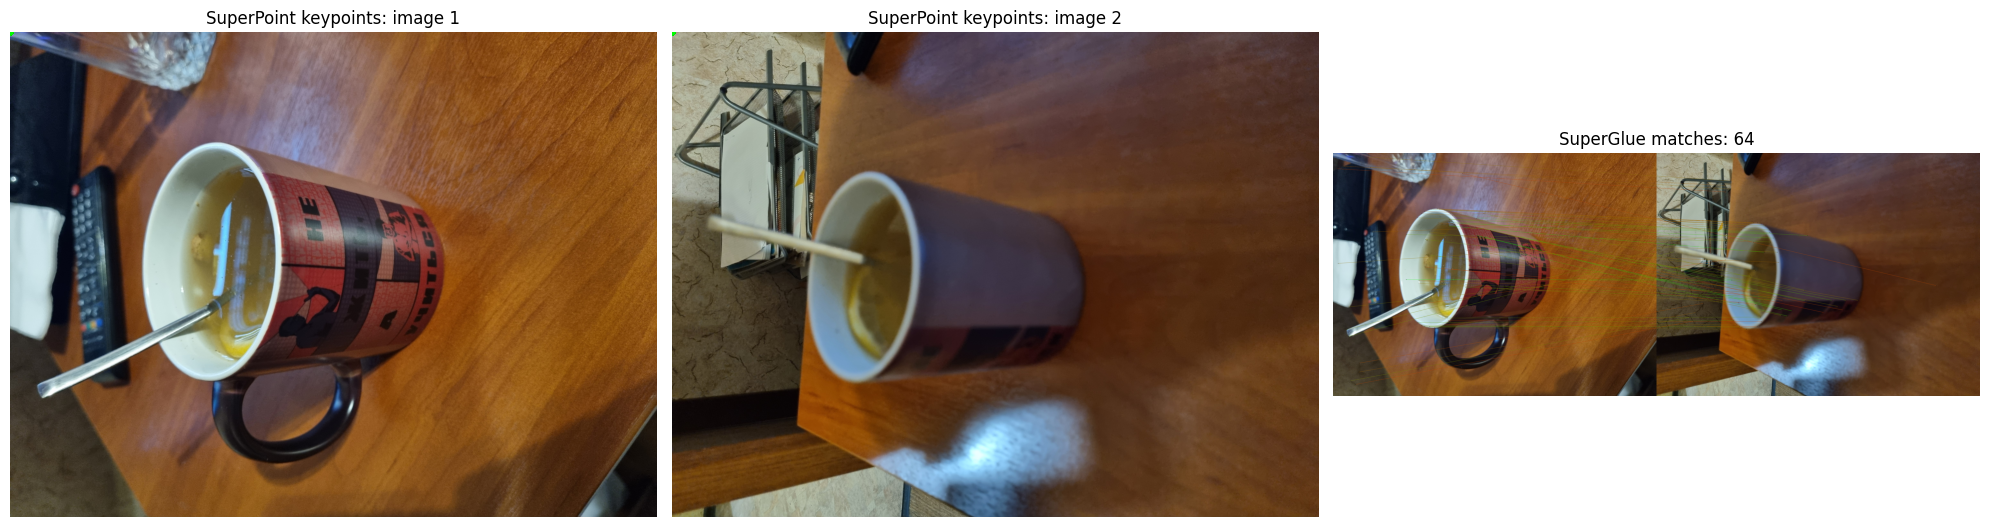

SuperPoint keypoints on image 1: 440
SuperPoint keypoints on image 2: 353
SuperGlue matches: 64


In [33]:
from pathlib import Path
from PIL import Image
import torch
from transformers import (
    SuperPointImageProcessor,
    SuperPointForKeypointDetection,
    SuperGlueImageProcessor,
    SuperGlueForKeypointMatching,
)

cache_dir = Path('data/hf_cache')

superpoint_processor = SuperPointImageProcessor.from_pretrained(
    'magic-leap-community/superpoint',
    cache_dir=cache_dir,
    local_files_only=True,
)
superpoint_model = SuperPointForKeypointDetection.from_pretrained(
    'magic-leap-community/superpoint',
    cache_dir=cache_dir,
    local_files_only=True,
)
superglue_processor = SuperGlueImageProcessor.from_pretrained(
    'magic-leap-community/superglue_outdoor',
    cache_dir=cache_dir,
    local_files_only=True,
)
superglue_model = SuperGlueForKeypointMatching.from_pretrained(
    'magic-leap-community/superglue_outdoor',
    cache_dir=cache_dir,
    local_files_only=True,
)

image_0 = Image.open('data/tea_1.jpg').convert('RGB')
image_1 = Image.open('data/tea_2.jpg').convert('RGB')

superpoint_kps = []
for image in [image_0, image_1]:
    inputs = superpoint_processor(image, return_tensors='pt')
    with torch.no_grad():
        outputs = superpoint_model(**inputs)
    superpoint_kps.append(outputs.keypoints[0].cpu().numpy())

inputs = superglue_processor(images=[image_0, image_1], return_tensors='pt')
with torch.no_grad():
    matching_outputs = superglue_model(**inputs)
matches = superglue_processor.post_process_keypoint_matching(
    matching_outputs,
    target_sizes=[[(image_0.height, image_0.width), (image_1.height, image_1.width)]],
    threshold=0.2,
)
match_vis = superglue_processor.visualize_keypoint_matching([image_0, image_1], matches)[0]

fig, axs = plt.subplots(1, 3, figsize=(20, 6))
for ax, image, kps, title in zip(
    axs[:2],
    [image_0, image_1],
    superpoint_kps,
    ['SuperPoint keypoints: image 1', 'SuperPoint keypoints: image 2'],
):
    ax.imshow(image)
    ax.scatter(kps[:, 0], kps[:, 1], s=8, c='lime', alpha=0.7)
    ax.set_title(title)
    ax.axis('off')

axs[2].imshow(match_vis)
axs[2].set_title(f'SuperGlue matches: {matches[0]["keypoints0"].shape[0]}')
axs[2].axis('off')
plt.tight_layout()
plt.show()

print('SuperPoint keypoints on image 1:', superpoint_kps[0].shape[0])
print('SuperPoint keypoints on image 2:', superpoint_kps[1].shape[0])
print('SuperGlue matches:', matches[0]['keypoints0'].shape[0])


## Задание 3 (исследовательское)

Найдите свежий нейросетевой метод (2023 и моложе), реализующий детекцию и сопоставление ключевых точек (можно два метода, если они работают последовательно).
Напишите краткий обзор этого метода:
- Краткое описание (summary);
- Достоинства метода;
- Недостатки метода.

Ответ (обзор) - пишите в Markdown ячейке в этом ноутбуке.

## Обзор метода: XFeat (CVPR 2024)

**Summary.** XFeat (Accelerated Features for Lightweight Image Matching) — это легкий нейросетевой метод для извлечения признаков и сопоставления изображений. Он ориентирован на высокую скорость и низкую вычислительную стоимость, поэтому хорошо подходит для real-time задач, SLAM и visual localization. В отличие от тяжелых трансформерных матчеров, XFeat делает ставку на баланс между точностью и производительностью.

**Достоинства.**
- Очень быстрый и легкий: подходит для CPU- и GPU-инференса.
- Дает хороший компромисс между скоростью и качеством матчинга.
- Умеет работать как в sparse-, так и в semi-dense режиме.
- Практичен для робототехники, visual odometry и embedded-сценариев.

**Недостатки.**
- По точности на самых сложных wide-baseline сценариях может уступать более тяжелым трансформерным матчерам.
- Качество зависит от домена: при сильном domain shift нужна дотренировка.
- В малотекстурных областях sparse-режим может пропускать часть полезных соответствий.

**Источник:** Potje et al., "XFeat: Accelerated Features for Lightweight Image Matching", CVPR 2024. https://arxiv.org/abs/2404.19174
